# 02 — Neural Tabular : DNN, TabTransformer, FT-Transformer

**Pipeline preprocessing NN :**
- Target encoding pour cat haute cardinalité
- QuantileTransformer sur numériques
- Embeddings appris pour cat basse cardinalité
- Split **train / val / test** (60/20/20) temporel
- Métriques **AUC-ROC + AUC-PR** sur val ET test
- Class weighting pour gérer le déséquilibre

**Lib :** pytorch-tabular

**⚠️ GPU :** sur Kaggle, utiliser **T4 x2** (pas P100, incompatible avec les kernels torch récents).
Pour les Transformers, `batch_size=512` évite l'OOM.

## 1. Install + imports

In [1]:
!pip install -q pytorch-tabular[extra] category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 23.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 88.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 12.3 MB/s eta 0:00:00


In [2]:
import gc, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from sklearn.preprocessing import QuantileTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from category_encoders import TargetEncoder
from pytorch_tabular import TabularModel
from pytorch_tabular.models import CategoryEmbeddingModelConfig, TabTransformerConfig, FTTransformerConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
from pytorch_tabular.utils import get_class_weighted_cross_entropy
import warnings; warnings.filterwarnings('ignore')

train = pd.read_pickle('/kaggle/input/notebooks/simoben95/00-01common-preprocessing/train_base.pkl')
test_kaggle  = pd.read_pickle('/kaggle/input/notebooks/simoben95/00-01common-preprocessing/test_kaggle.pkl')
print(train.shape, test_kaggle.shape, '| GPU:', torch.cuda.is_available())

(590540, 427) (506691, 426) | GPU: True


## 2. Split temporel train / val / test (60/20/20)

In [3]:
train_sorted = train.sort_values('TransactionDT').reset_index(drop=True)
n = len(train_sorted); i1, i2 = int(n*0.6), int(n*0.8)
tr_df  = train_sorted.iloc[:i1].copy()
val_df = train_sorted.iloc[i1:i2].copy()
te_df  = train_sorted.iloc[i2:].copy()
print(f'Train: {len(tr_df):,} | Val: {len(val_df):,} | Test: {len(te_df):,}')

Train: 354,324 | Val: 118,108 | Test: 118,108


## 3. Séparer cat (basse/haute card) vs num

In [4]:
cat_cols = [c for c in tr_df.columns if tr_df[c].dtype == 'object']
num_cols = [c for c in tr_df.columns if c not in cat_cols + ['isFraud','TransactionID','TransactionDT','DT_M']]
card = {c: tr_df[c].nunique() for c in cat_cols}
cat_high = [c for c,n_ in card.items() if n_ > 50]
cat_low  = [c for c,n_ in card.items() if n_ <= 50]
print(f'Cat low: {len(cat_low)} | Cat high: {len(cat_high)} | Num: {len(num_cols)}')

Cat low: 30 | Cat high: 9 | Num: 384


## 4. Target encoding (haute cardinalité, fit sur train only !)

In [5]:
for c in cat_low:
    for d in [tr_df, val_df, te_df, test_kaggle]:
        d[c] = d[c].astype(str).fillna('missing')

te = TargetEncoder(cols=cat_high, smoothing=10.0)
tr_df[cat_high]       = te.fit_transform(tr_df[cat_high].astype(str).fillna('missing'), tr_df['isFraud'])
val_df[cat_high]      = te.transform(val_df[cat_high].astype(str).fillna('missing'))
te_df[cat_high]       = te.transform(te_df[cat_high].astype(str).fillna('missing'))
test_kaggle[cat_high] = te.transform(test_kaggle[cat_high].astype(str).fillna('missing'))
num_cols = num_cols + cat_high

## 5. Imputation médiane + QuantileTransformer (fit sur train only)

In [6]:
imp = SimpleImputer(strategy='median')
tr_df[num_cols]       = imp.fit_transform(tr_df[num_cols])
val_df[num_cols]      = imp.transform(val_df[num_cols])
te_df[num_cols]       = imp.transform(te_df[num_cols])
test_kaggle[num_cols] = imp.transform(test_kaggle[num_cols])

qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42, subsample=200000)
tr_df[num_cols]       = qt.fit_transform(tr_df[num_cols]).astype(np.float32)
val_df[num_cols]      = qt.transform(val_df[num_cols]).astype(np.float32)
te_df[num_cols]       = qt.transform(te_df[num_cols]).astype(np.float32)
test_kaggle[num_cols] = qt.transform(test_kaggle[num_cols]).astype(np.float32)

## 6. Fonction d'évaluation + helper proba

In [7]:
results = []
def evaluate(y_true, y_pred, name, split_name, ax_roc=None, ax_pr=None, color=None):
    auc_roc = roc_auc_score(y_true, y_pred); auc_pr = average_precision_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_pred); pr, rc, _ = precision_recall_curve(y_true, y_pred)
    if ax_roc is not None: ax_roc.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc_roc:.4f})')
    if ax_pr  is not None: ax_pr.plot(rc, pr,   color=color, label=f'{name} (AP={auc_pr:.4f})')
    print(f'  {split_name:5s} | AUC-ROC: {auc_roc:.4f} | AUC-PR: {auc_pr:.4f}')
    results.append({'model': name, 'split': split_name, 'auc_roc': auc_roc, 'auc_pr': auc_pr})

def get_pos_proba(model, df):
    pred_df = model.predict(df)
    prob_cols = [c for c in pred_df.columns if c.endswith('_probability')]
    return pred_df[prob_cols[-1]].values

y_val = val_df['isFraud'].values
y_te  = te_df['isFraud'].values

## 7. Configs communes

`accelerator='gpu'` sur Kaggle T4. Metrics = AUC-ROC + AUC-PR (via torchmetrics multiclass num_classes=2).
Class weighting via `get_class_weighted_cross_entropy` pour gérer le déséquilibre.

In [8]:
data_cfg = DataConfig(target=['isFraud'], continuous_cols=num_cols, categorical_cols=cat_low)

# Trainer pour MLP (batch grand)
trainer_cfg_mlp = TrainerConfig(batch_size=4096, max_epochs=15, accelerator='gpu', devices=1,
                                early_stopping='valid_loss', early_stopping_patience=3)
# Trainer pour Transformers (batch plus petit -> évite OOM)
trainer_cfg_tf  = TrainerConfig(batch_size=512,  max_epochs=15, accelerator='gpu', devices=1,
                                early_stopping='valid_loss', early_stopping_patience=3)
opt_cfg = OptimizerConfig()

METRICS = ['auroc', 'average_precision']
METRICS_PROB = [True, True]
METRICS_PARAMS = [
    {'task': 'multiclass', 'num_classes': 2},
    {'task': 'multiclass', 'num_classes': 2},
]

# Class weighting (fraude ≈ 3.5%)
weighted_loss = get_class_weighted_cross_entropy(tr_df['isFraud'].values.astype(int), mu=0.15)

## 8. DNN (MLP baseline)

In [9]:
%%time
dnn_cfg = CategoryEmbeddingModelConfig(
    task='classification', layers='256-128-64', dropout=0.2, learning_rate=1e-3,
    metrics=METRICS, metrics_prob_input=METRICS_PROB, metrics_params=METRICS_PARAMS,
)
m_dnn = TabularModel(data_config=data_cfg, model_config=dnn_cfg,
                     optimizer_config=opt_cfg, trainer_config=trainer_cfg_mlp)
m_dnn.fit(train=tr_df, validation=val_df, loss=weighted_loss)

pred_dnn_val = get_pos_proba(m_dnn, val_df)
pred_dnn_te  = get_pos_proba(m_dnn, te_df)
print('DNN:'); evaluate(y_val, pred_dnn_val, 'DNN', 'val')
evaluate(y_te,  pred_dnn_te,  'DNN', 'test')

2026-04-16 17:50:50,539 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
Seed set to 42
2026-04-16 17:50:50,583 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-04-16 17:50:53,050 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for classification task
2026-04-16 17:51:00,760 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: CategoryEmbeddingModel
2026-04-16 17:51:02,323 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-04-16 17:51:02,379 - {pytorch_tabular.tabular_model:677} - INFO - Training Started
2026-04-16 17:51:05.014561: E external/local_xla/xl

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ custom_loss      │ CrossEntropyLoss          │      0 │ train │     0 │
│ 1 │ _backbone        │ CategoryEmbeddingBackbone │  173 K │ train │     0 │
│ 2 │ _embedding_layer │ Embedding1dLayer          │  3.4 K │ train │     0 │
│ 3 │ head             │ LinearHead                │    130 │ train │     0 │
└───┴──────────────────┴───────────────────────────┴────────┴───────┴───────┘

Trainable params: 177 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 177 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 49                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

2026-04-16 17:52:52,174 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-04-16 17:52:52,175 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model


DNN:
  val   | AUC-ROC: 0.8867 | AUC-PR: 0.5100
  test  | AUC-ROC: 0.8642 | AUC-PR: 0.4456
CPU times: user 2min 15s, sys: 4.25 s, total: 2min 20s
Wall time: 2min 8s


## 9. TabTransformer

In [11]:
%%time
del m_dnn; gc.collect(); torch.cuda.empty_cache()

tt_cfg = TabTransformerConfig(
    task='classification', input_embed_dim=32, num_attn_blocks=3, num_heads=4, learning_rate=1e-4,
    metrics=METRICS, metrics_prob_input=METRICS_PROB, metrics_params=METRICS_PARAMS,
)
m_tt = TabularModel(data_config=data_cfg, model_config=tt_cfg,
                    optimizer_config=opt_cfg, trainer_config=trainer_cfg_tf)
m_tt.fit(train=tr_df, validation=val_df, loss=weighted_loss)

pred_tt_val = get_pos_proba(m_tt, val_df)
pred_tt_te  = get_pos_proba(m_tt, te_df)
print('TabTransformer:'); evaluate(y_val, pred_tt_val, 'TabTransformer', 'val')
evaluate(y_te,  pred_tt_te,  'TabTransformer', 'test')

2026-04-16 17:54:29,897 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
Seed set to 42
2026-04-16 17:54:29,934 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-04-16 17:54:32,526 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for classification task
2026-04-16 17:54:40,388 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: TabTransformerModel
2026-04-16 17:54:42,006 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-04-16 17:54:42,064 - {pytorch_tabular.tabular_model:677} - INFO - Training Started
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ custom_loss      │ CrossEntropyLoss       │      0 │ train │     0 │
│ 1 │ _backbone        │ TabTransformerBackbone │ 87.3 K │ train │     0 │
│ 2 │ _embedding_layer │ Embedding2dLayer       │  8.0 K │ train │     0 │
│ 3 │ _head            │ LinearHead             │  2.7 K │ train │     0 │
└───┴──────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 98.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 98.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 125                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

2026-04-16 18:00:37,855 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-04-16 18:00:37,856 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model


TabTransformer:
  val   | AUC-ROC: 0.8718 | AUC-PR: 0.4495
  test  | AUC-ROC: 0.8557 | AUC-PR: 0.4000
CPU times: user 9min 29s, sys: 13.6 s, total: 9min 42s
Wall time: 6min 43s


## 10. FT-Transformer

In [12]:
%%time
del m_tt; gc.collect(); torch.cuda.empty_cache()

ft_cfg = FTTransformerConfig(
    task='classification', input_embed_dim=16, num_attn_blocks=2, num_heads=4, learning_rate=1e-4,
    metrics=METRICS, metrics_prob_input=METRICS_PROB, metrics_params=METRICS_PARAMS,
)
m_ft = TabularModel(data_config=data_cfg, model_config=ft_cfg,
                    optimizer_config=opt_cfg, trainer_config=trainer_cfg_tf)
m_ft.fit(train=tr_df, validation=val_df, loss=weighted_loss)

pred_ft_val = get_pos_proba(m_ft, val_df)
pred_ft_te  = get_pos_proba(m_ft, te_df)
print('FT-Transformer:'); evaluate(y_val, pred_ft_val, 'FT-Transformer', 'val')
evaluate(y_te,  pred_ft_te,  'FT-Transformer', 'test')

2026-04-16 18:02:04,597 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
Seed set to 42
2026-04-16 18:02:04,633 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-04-16 18:02:07,151 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for classification task
2026-04-16 18:02:15,034 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: FTTransformerModel
2026-04-16 18:02:16,960 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-04-16 18:02:17,015 - {pytorch_tabular.tabular_model:677} - INFO - Training Started
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ custom_loss      │ CrossEntropyLoss      │      0 │ train │     0 │
│ 1 │ _backbone        │ FTTransformerBackbone │ 15.3 K │ train │     0 │
│ 2 │ _embedding_layer │ Embedding2dLayer      │ 17.9 K │ train │     0 │
│ 3 │ _head            │ LinearHead            │     34 │ train │     0 │
└───┴──────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 33.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 110                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

2026-04-16 19:13:38,745 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-04-16 19:13:38,746 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model


FT-Transformer:
  val   | AUC-ROC: 0.8737 | AUC-PR: 0.4682
  test  | AUC-ROC: 0.8580 | AUC-PR: 0.4130
CPU times: user 1h 45min 7s, sys: 44min 49s, total: 2h 29min 56s
Wall time: 1h 51min 13s


## 11. Comparaison + courbes (sur test)

  test  | AUC-ROC: 0.8642 | AUC-PR: 0.4456
  test  | AUC-ROC: 0.8557 | AUC-PR: 0.4000
  test  | AUC-ROC: 0.8580 | AUC-PR: 0.4130


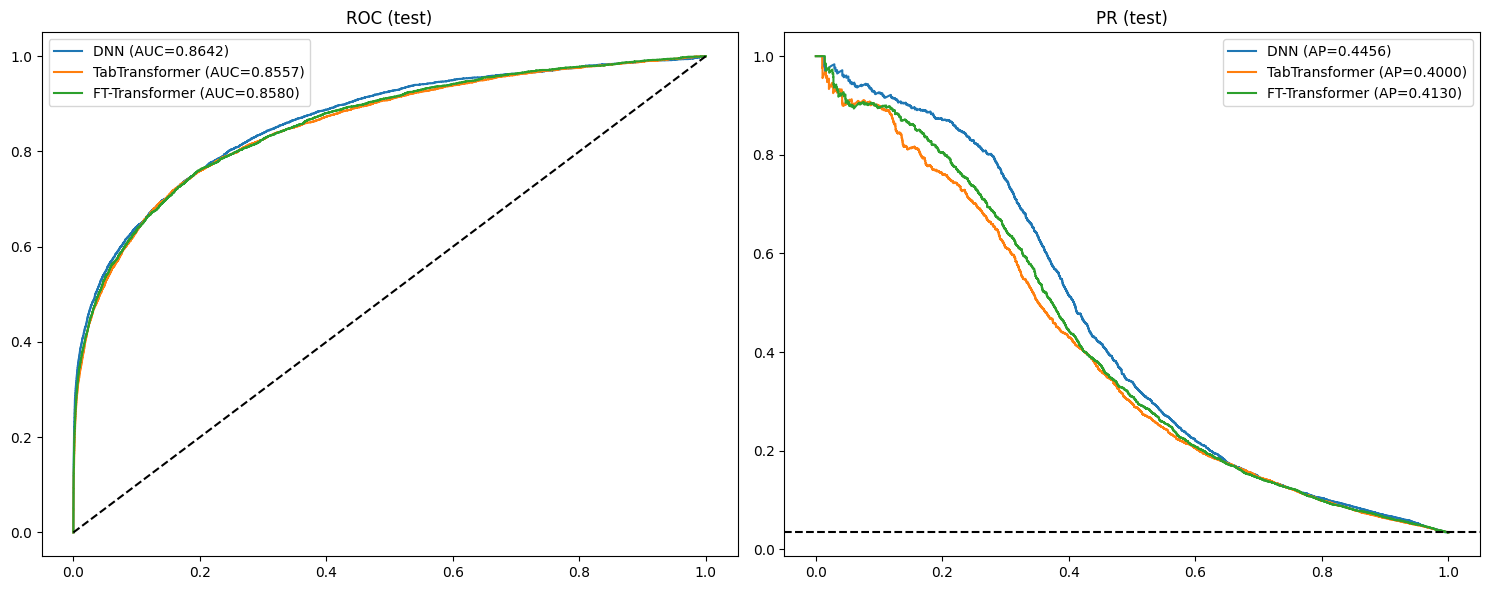

auc_pr             auc_roc          
split               test       val      test       val
model                                                 
DNN             0.445550  0.509957  0.864155  0.886736
FT-Transformer  0.413017  0.468195  0.857992  0.873676
TabTransformer  0.400018  0.449536  0.855664  0.871754

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
evaluate(y_te, pred_dnn_te, 'DNN',            'test', ax1, ax2, 'C0')
evaluate(y_te, pred_tt_te,  'TabTransformer', 'test', ax1, ax2, 'C1')
evaluate(y_te, pred_ft_te,  'FT-Transformer', 'test', ax1, ax2, 'C2')
ax1.plot([0,1],[0,1],'k--'); ax1.set_title('ROC (test)'); ax1.legend()
ax2.axhline(y_te.mean(), color='k', ls='--'); ax2.set_title('PR (test)'); ax2.legend()
plt.tight_layout(); plt.show()
pd.DataFrame(results).pivot_table(index='model', columns='split', values=['auc_roc','auc_pr'])

## 12. Soumission Kaggle (FT-Transformer)

In [16]:
test_pred = get_pos_proba(m_ft, test_kaggle)
sub = pd.DataFrame({'TransactionID': test_kaggle['TransactionID'], 'isFraud': test_pred})
sub.to_csv('/kaggle/working/submission_neural.csv', index=False)
print(sub.head())

   TransactionID   isFraud
0        3663549  0.006485
1        3663550  0.013941
2        3663551  0.042351
3        3663552  0.010668
4        3663553  0.028057
